# Analyzing ADHD, Anxiety, and Depression in Children: A Python Skills Project
*By: Sarah Shelton*

*CHIP335: Introduction to Programming with Alex Harding*

**Disclaimer: The purpose of this document is to demonstrate the Python skills learned in CHIP335 including fetching data from the web, working with dataframes, and creating visualizations. Although the data is real, the emphasis is on practicing Python skills, not on the accruacy or depth of the analysis.**

### **Introduction:**
This research is based on a personal interest in looking at the comorbidity of Attention Deficit Hyperactivity Disorder (ADHD), anxiety, and depression. To narrow the scope of the project, a data set available through the CDC was used. This data set consists of a sample size of 3,018 children between 2-15 years old in 2011-2012 whose parents or guardians reported a prior diagnosis of ADHD or Tourette’s syndrome by a healthcare provider and who were still under 18 during a later re-interview. 

### **Research Question:**
What are the most prominent comorbidities of ADHD in this data set?

### Accessing the Data

**Data Source:** 
Data was obtained from the CDC archive for the National Survey of the Diagnosis and Treatment of ADHD and Tourette Syndrome (NS-DATA). This project was sponsored by the National Center on Birth Defects and Developmental Disabilities (NCBDDD) and the National Center for Health Statistics. This dataset was last reviewed on February 15, 2022 and archived on November 20, 2024.

The link below directs users to the CDC archive page, which provides access to the dataset (available in SAS format) along additional information regarding sampling methodology, variable lists and frequency counts, and related reports.

Data from CDC Archive URL: https://archive.cdc.gov/www_cdc_gov/nchs/slaits/ns_data.htm

In [344]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [345]:
# Loading the SAS dataset
sas_path = "nsdata_adhd_puf_u.sas7bdat"
df, meta = pyreadstat.read_sas7bdat(sas_path)

### Identifying the variables associated with common ADHD comorbidities to simplify data analysis and enable efficient extraction of relevant information for each condition.

In [346]:
comorbidity_keywords = {
    "anxiety": ["anxiety", "anxious", "anxiolytic"],
    "depression": ["depression", "antidepressant", "depressive"],
    "behavior": ["behavior", "behavioral", "conduct", "oppositional"],
    "learning": ["learning", "dyslexia", "reading"],
    "sleep": ["sleep", "insomnia", "sleep disorder"],
    "asthma": ["asthma"],
    "allergy": ["allergy", "allergic"],
    "headache": ["headache", "migraine"],
    "speech": ["speech", "language"],
    "tic": ["tic", "tourette"],
    "autism": ["autism", "autistic", "spectrum"],
}

comorbidity_vars = {}
for condition, keywords in comorbidity_keywords.items():
    condition_vars = []
    for var in meta.column_names:
        label = meta.column_names_to_labels.get(var, "")
        if any(keyword.lower() in label.lower() for keyword in keywords):
            condition_vars.append((var, label))
    if condition_vars:
        comorbidity_vars[condition] = condition_vars

print("List of comorbidities and related variables found in dataset:")
for condition, vars_list in comorbidity_vars.items():
    print(f"\n{condition.upper()}:")
    for var, label in vars_list:
        print(f"  {var}: {label}")

List of comorbidities and related variables found in dataset:

ANXIETY:
  ADHD_A4_1CA_X03: What was the diagnosis changed to? - Anxiety (NORC back coded)
  ADHD_B1_1_10: Has a doctor or health care provider ever told you that [S.C.] had another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
  ADHD_B1_2_10: Does [S.C.] currently have another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
  ADHD_MEDS_CLASS_6: DERIVED. [S.C.] currently takes an anxiolytic for ADHD

DEPRESSION:
  ADHD_A4_1CA_X04: What was the diagnosis changed to? - Depression (NORC back coded)
  ADHD_B1_1_13: Has a doctor or health care provider ever told you that [S.C.] had another mood disorder, such as depression, major depressive disorder or dysthymic disorder?
  ADHD_B1_2_13: Does [S.C.] currently have another mood disorder, such as depression, major depressive disorder or dysthymic disorder?
  ADHD_MEDS_CLASS_2: DERIVED. [S.C.] currently tak

<font color="red"> The following codeblock does not need to be run, but was generated to help determine how to approach data analysis and data extraction </font>

In [347]:
# Count responses for each variable
comorbidity_summary = []
for condition, vars_list in comorbidity_vars.items():
    print(f"\n{condition.upper()}:")
    for var, label in vars_list:
        value_counts = df[var].value_counts()
        total_responses = df[var].count()
        print(f"  {var}: {label}")
        print(f"    Total responses: {total_responses}")
        print(f"    Value counts:\n{df[var].value_counts().to_string()}\n")
        
        # Stores count and response value in a structured comorbidity summary table for each variable
        for value, count in value_counts.items():
                percentage = (count / total_responses) * 100 if total_responses > 0 else 0
                comorbidity_summary.append({
                    'Condition': condition,
                    'Variable': var,
                    'Value': value,
                    'Count': count,
                    "Percentage" : percentage,
                    'Total_Responses': total_responses
                })


ANXIETY:
  ADHD_A4_1CA_X03: What was the diagnosis changed to? - Anxiety (NORC back coded)
    Total responses: 130
    Value counts:
ADHD_A4_1CA_X03
0.0    64
5.0    35
1.0    25
6.0     6

  ADHD_B1_1_10: Has a doctor or health care provider ever told you that [S.C.] had another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
    Total responses: 2966
    Value counts:
ADHD_B1_1_10
0.0    2324
1.0     629
6.0      13

  ADHD_B1_2_10: Does [S.C.] currently have another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
    Total responses: 629
    Value counts:
ADHD_B1_2_10
1.0    483
0.0    138
6.0      8

  ADHD_MEDS_CLASS_6: DERIVED. [S.C.] currently takes an anxiolytic for ADHD
    Total responses: 1752
    Value counts:
ADHD_MEDS_CLASS_6
0.0    1746
1.0       6


DEPRESSION:
  ADHD_A4_1CA_X04: What was the diagnosis changed to? - Depression (NORC back coded)
    Total responses: 130
    Value counts:
ADHD_A4_

## Prevalence Summary of ADHD Comorbidities

In [348]:
# A summary table to compare comorbidities by condition. Calculates total cases, responses, and prevalence percentages for each condition.
summary_table = []
for condition, vars_list in comorbidity_vars.items():
    condition_cols = [var for var, label in vars_list]
    condition_df = df[condition_cols]
    total_count = (condition_df == 1.0).any(axis=1).sum()
    total_responses = condition_df.notna().any(axis=1).sum()
    percentage = (total_count / total_responses * 100) if total_responses > 0 else 0

    summary_table.append({
        'Condition': condition,
        'Total_Cases': int(total_count),
        'Total_Responses': int(total_responses),
        'Percentage': round(percentage, 1),
    })

final_summary = pd.DataFrame(summary_table).sort_values('Percentage', ascending=False)

print("Top comorbidities of ADHD by Prevalence:")
print(f"\n{final_summary.to_string(index=False)}")


Top comorbidities of ADHD by Prevalence:

 Condition  Total_Cases  Total_Responses  Percentage
  behavior         2963             2966        99.9
       tic         1578             2966        53.2
     sleep         1552             2966        52.3
  learning         1327             2966        44.7
  headache          929             2647        35.1
depression          668             2966        22.5
   anxiety          635             2966        21.4
    speech          561             2966        18.9
    autism          506             2966        17.1
   allergy           23             2647         0.9


Top comorbidities of ADHD by Prevalence:


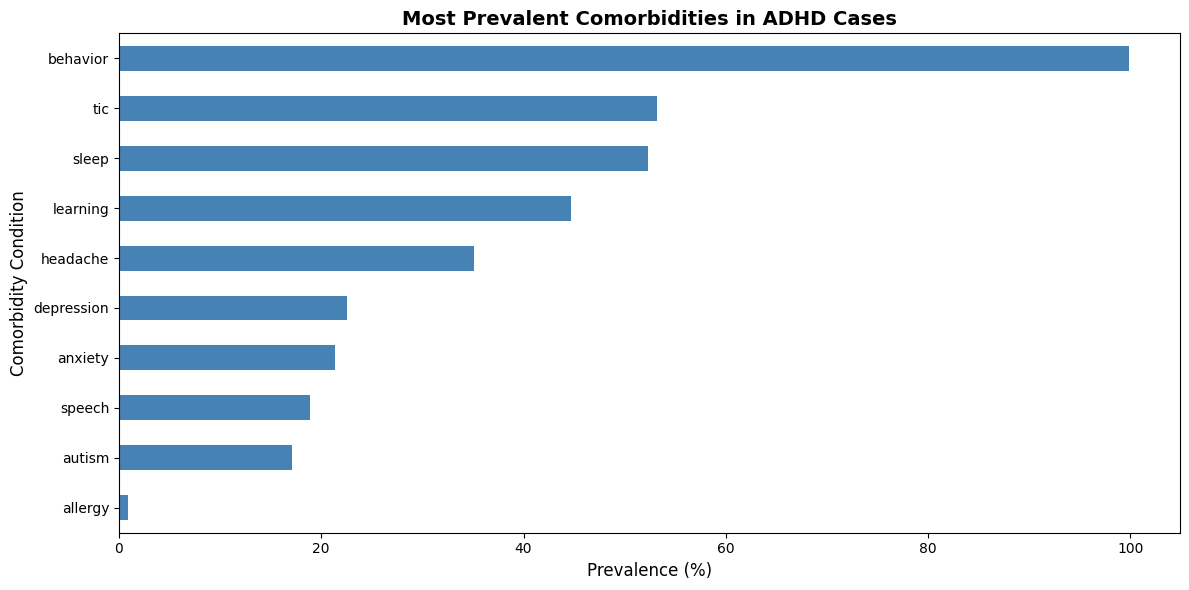

In [349]:
#Visualization of most prevalent comorbidities in ADHD cases
top_conditions = final_summary.set_index('Condition')['Percentage'].sort_values(ascending=True)
print("Top comorbidities of ADHD by Prevalence:")
plt.figure(figsize=(12, 6))
top_conditions.plot(kind='barh', color='steelblue')
plt.xlabel('Prevalence (%)', fontsize=12)
plt.ylabel('Comorbidity Condition', fontsize=12)
plt.title('Most Prevalent Comorbidities in ADHD Cases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion to Research Question:
### The most prevalent comorbidity associated with ADHD is behavioral issues, affecting nearly all individuals with ADHD (99.9%). Other common comorbidities include tic disorders, sleep problems, learning difficulties, headaches. Mental health conditions such as depression (22.5%) and anxiety (21.4%) also show significant prevalence among the population studied. Less common comorbidities include speech difficulties, autism, and allergies. These findings highlight the diverse and range of behavioral and neurological conditions that often accompany ADHD within this dataset.

## Follow Up Question: 
### How frequently are anxiety and depression diagnosed as comorbid conditions in individuals with ADHD, and what are the patterns in diagnosis changes and current treatment related to these two conditions?

### Finding variables specifically related to anxiety and depression.

In [350]:
# Define keywords only for anxiety and depression
target_conditions = {
    "anxiety": comorbidity_keywords.get("anxiety", []),
    "depression": comorbidity_keywords.get("depression", [])
}

# Edited to include only the target conditions and to help determine which variables to analyze and compare.
comorbidity_vars = {}
for condition, keywords in target_conditions.items():
    condition_vars = []
    for var in meta.column_names:
        label = meta.column_names_to_labels.get(var, "")
        if any(keyword.lower() in label.lower() for keyword in keywords):
            condition_vars.append((var, label))
    if condition_vars:
        comorbidity_vars[condition] = condition_vars

print("Variables related to anxiety and depression found in dataset:")
for condition, vars_list in comorbidity_vars.items():
    print(f"\n{condition.upper()}:")
    for var, label in vars_list:
        print(f"Variable Name: {var}\nVariable Label: {label}\n")

Variables related to anxiety and depression found in dataset:

ANXIETY:
Variable Name: ADHD_A4_1CA_X03
Variable Label: What was the diagnosis changed to? - Anxiety (NORC back coded)

Variable Name: ADHD_B1_1_10
Variable Label: Has a doctor or health care provider ever told you that [S.C.] had another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?

Variable Name: ADHD_B1_2_10
Variable Label: Does [S.C.] currently have another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?

Variable Name: ADHD_MEDS_CLASS_6
Variable Label: DERIVED. [S.C.] currently takes an anxiolytic for ADHD


DEPRESSION:
Variable Name: ADHD_A4_1CA_X04
Variable Label: What was the diagnosis changed to? - Depression (NORC back coded)

Variable Name: ADHD_B1_1_13
Variable Label: Has a doctor or health care provider ever told you that [S.C.] had another mood disorder, such as depression, major depressive disorder or dysthymic disorder?

Variable Na

## Positive Cases for Anxiety and Depression

In [361]:
comorbidity_summary = []
target_conditions = {
    "anxiety": comorbidity_keywords.get("anxiety", []),
    "depression": comorbidity_keywords.get("depression", [])
}
target_value = 1.0
comorbidity_vars = {}

for condition in target_conditions:
    condition_vars = []
    for var in meta.column_names:
        label = meta.column_names_to_labels.get(var, "")
        if any(keyword.lower() in label.lower() for keyword in keywords):
            condition_vars.append((var, label))
    if condition_vars:
        comorbidity_vars[condition] = condition_vars
        

    for var, label in condition_vars:
        value_counts = df[var].value_counts()
        total_responses = df[var].count()
        count = value_counts.get(target_value, 0)
        percentage = (count / total_responses * 100) if total_responses > 0 else 0
       
        comorbidity_summary.append({
            'Condition': condition,
            'Variable': var,
            'Value': target_value,
            'Count': count,
            'Percentage': percentage,
            'Total_Responses': total_responses
        })

# Dataframe with detailed info for anxiety and depression, value=1.0
positive_filtered_df = pd.DataFrame(comorbidity_summary)

print("Positive cases for Anxiety and Depression:")
print(positive_filtered_df.to_string(index=False))

Positive cases for Anxiety and Depression:
 Condition          Variable  Value  Count  Percentage  Total_Responses
   anxiety   ADHD_A4_1CA_X04    1.0      7    5.384615              130
   anxiety      ADHD_B1_1_13    1.0    558   18.813216             2966
   anxiety      ADHD_B1_2_13    1.0    393   70.430108              558
   anxiety ADHD_MEDS_CLASS_2    1.0    173    9.874429             1752
depression   ADHD_A4_1CA_X04    1.0      7    5.384615              130
depression      ADHD_B1_1_13    1.0    558   18.813216             2966
depression      ADHD_B1_2_13    1.0    393   70.430108              558
depression ADHD_MEDS_CLASS_2    1.0    173    9.874429             1752


# ADHD Diagnosis, Anxiety & Depression Comorbidities, and Medication Overview

### In the context of the survey, [S.C.] refers to the surveyed child.
### DISCLAIMER: For shortened text purposes on graph labels, 'anxiety disorder' refers to generalized anxiety disorder, panic disorder, or a phobia and 'mood disorder' refers to depression, major depressive disorder or dysthymic disorder

In the context of the survey, [S.C.] refers to the surveyed child.
DISCLAIMER: For shortened text purposes on graph labels, 'anxiety disorder' refers to generalized anxiety disorder, panic disorder, or a phobia and 'mood disorder' refers to depression, major depressive disorder or dysthymic disorder.


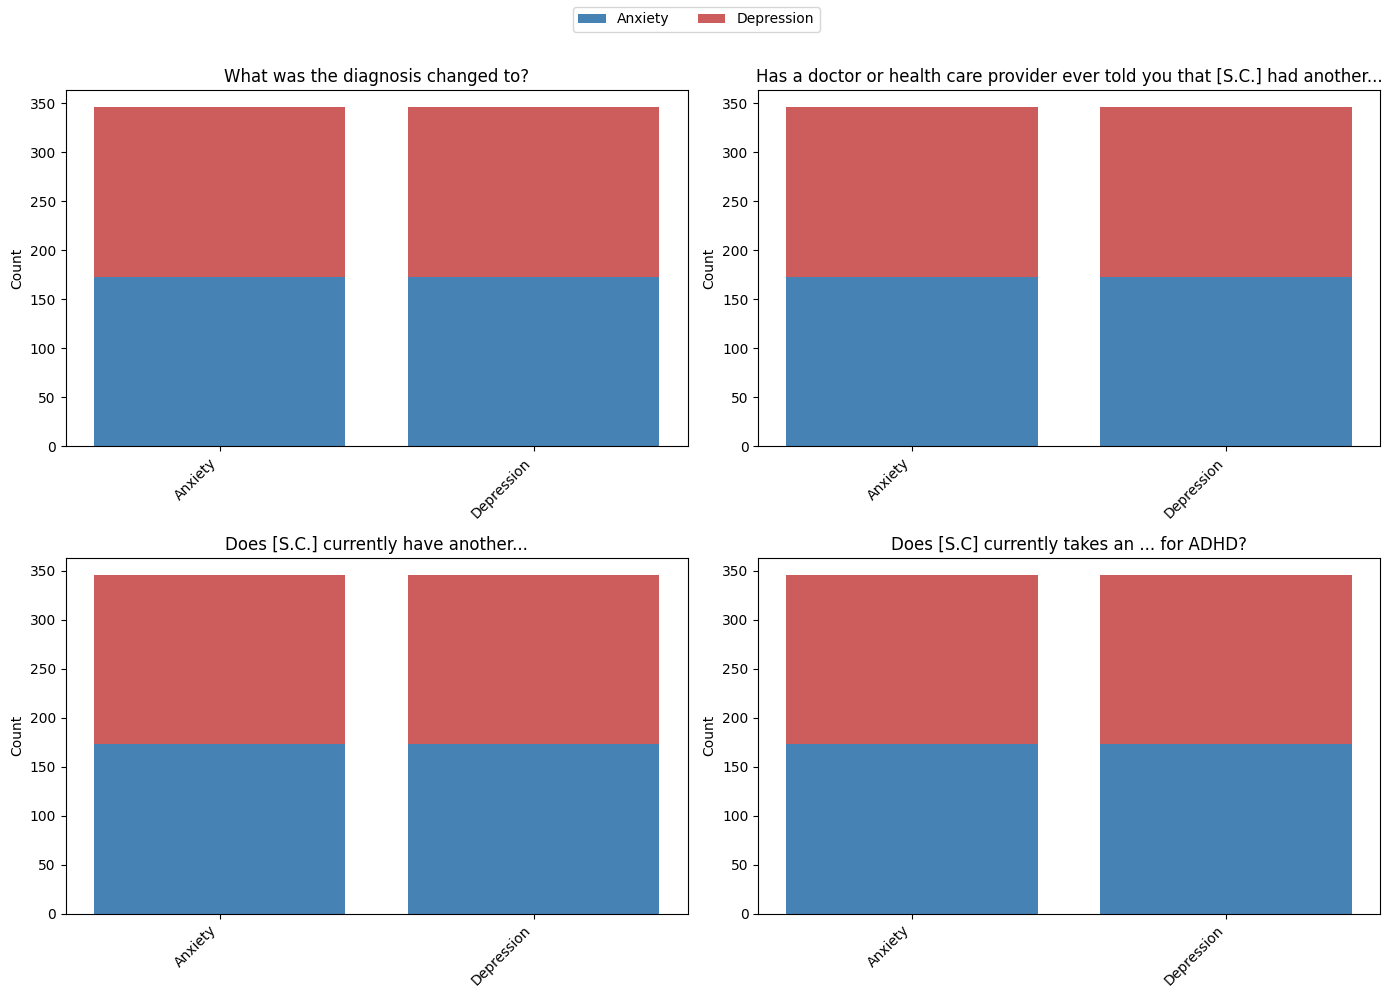

In [360]:
groups = [
    ["ADHD_A4_1CA_X03", "ADHD_A4_1CA_X04"],
    ["ADHD_B1_1_10", "ADHD_B1_1_13"],
    ["ADHD_B1_2_10", "ADHD_B1_2_13"],
    ["ADHD_MEDS_CLASS_6", "ADHD_MEDS_CLASS_2"]
]

# titles for subplots
titles = [
    "What was the diagnosis changed to?",
    "Has a doctor or health care provider ever told you that [S.C.] had another...",
    "Does [S.C.] currently have another...",
    "Does [S.C] currently takes an ... for ADHD?"
]

custom_labels = {
    "ADHD_A4_1CA_X03": "Anxiety (ADHD_A4_1CA_X03)",
    "ADHD_A4_1CA_X04": "Depression (DHD_A4_1CA_X04)",
    "ADHD_B1_1_10": "anxiety disorder (ADHD_B1_1_10)",
    "ADHD_B1_1_13": "mood disorder (ADHD_B1_1_13)",
    "ADHD_B1_2_10": "anxiety disorder (ADHD_B1_2_10)",
    "ADHD_B1_2_13": "mood disorder (ADHD_B1_2_13)",
    "ADHD_MEDS_CLASS_2": "antidepressant (ADHD_MEDS_CLASS_2)",
    "ADHD_MEDS_CLASS_6": "anxiolytic (ADHD_MEDS_CLASS_6)"
}
print("In the context of the survey, [S.C.] refers to the surveyed child.")
print("DISCLAIMER: For shortened text purposes on graph labels, 'anxiety disorder' refers to generalized anxiety disorder, panic disorder, or a phobia and 'mood disorder' refers to depression, major depressive disorder or dysthymic disorder.")

filtered_plot_df = positive_filtered_df[
    positive_filtered_df["Variable"].isin([v for group in groups for v in group])
]

pivot_df = (
    filtered_plot_df
    .pivot(index="Variable", columns="Condition", values="Count")
    .fillna(0)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var_group, title in zip(axes.flatten(), groups, titles):
    # existing_vars = [v for v in var_group if v in pivot_df.index]
    # labels = [custom_labels.get(v, v) for v in existing_vars]
    # subset = pivot_df.loc[existing_vars]
    # x = np.arange(len(labels))
    # width = 0.35
    ax.bar(labels, subset["anxiety"], label="Anxiety", color="steelblue")
    ax.bar(labels, subset["depression"], bottom=subset["anxiety"], label="Depression", color="indianred")

    # Setting each subplot title, axis labels, and legend
    ax.set_title(title)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Count")
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


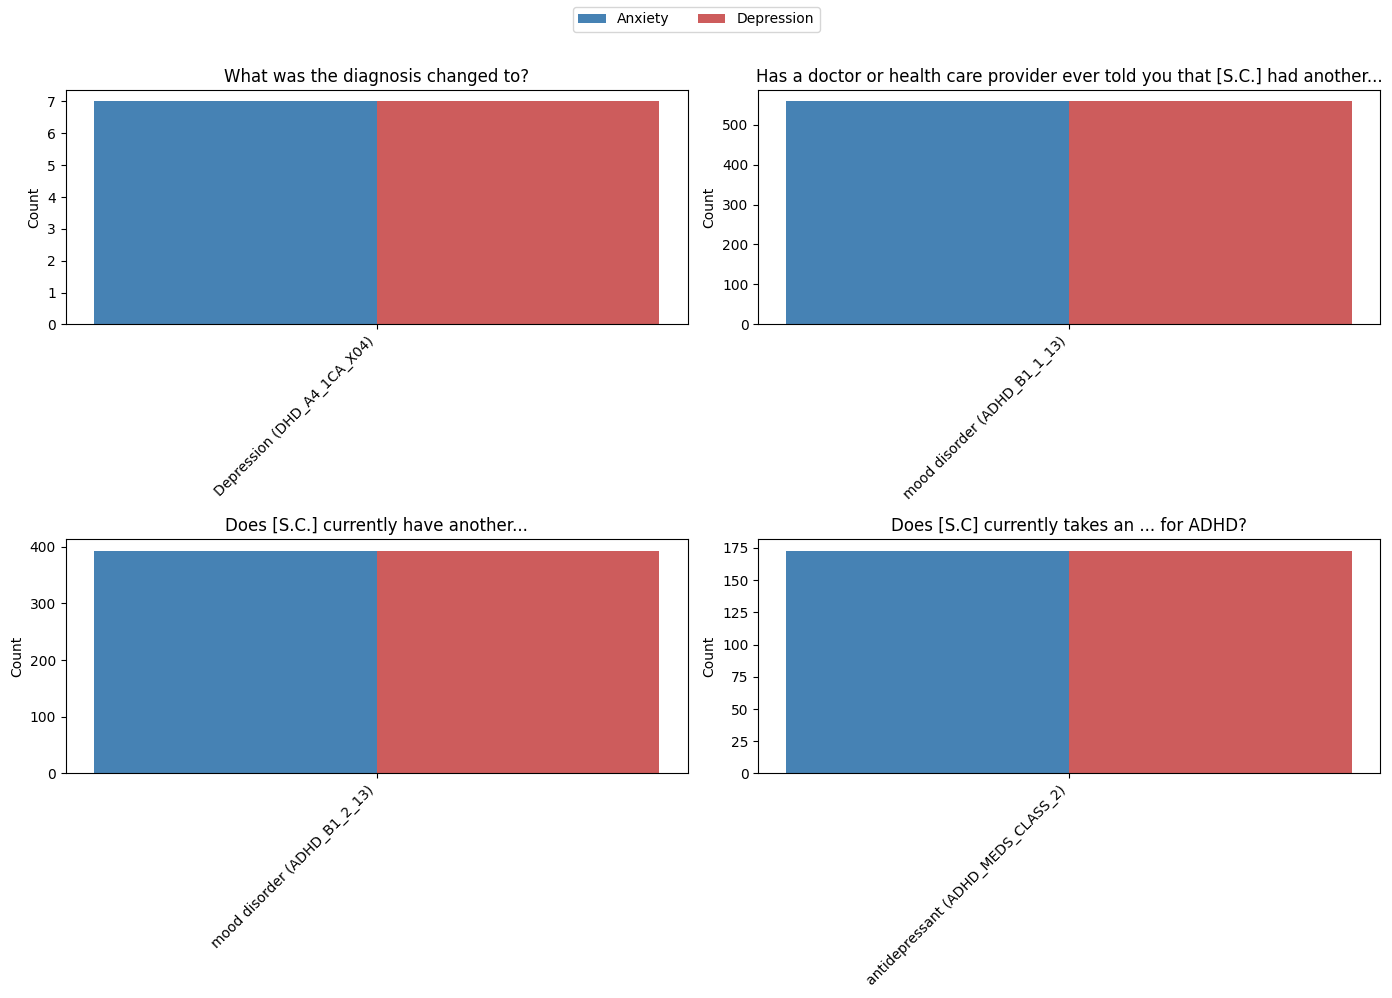

In [359]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var_group, title in zip(axes.flatten(), groups, titles):

    existing_vars = [v for v in var_group if v in pivot_df.index]
    labels = [custom_labels.get(v, v) for v in existing_vars]

    subset = pivot_df.loc[existing_vars]

    # numeric x positions
    x = np.arange(len(labels))
    width = 0.35  # width of each bar

    # side-by-side bars
    ax.bar(x - width/2, subset["anxiety"], width, 
           label="Anxiety", color="steelblue")

    ax.bar(x + width/2, subset["depression"], width, 
           label="Depression", color="indianred")

    # Title + labels
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Count")

# One legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Conclusion to Follow Up Question:

